# Gender detection ML model

## Importing

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

import pickle

## Read the Data

In [2]:
df = pd.read_csv ("../data/gender_classification_data.csv")
df

,gender,height,weight,age
0,female,166.835558,64.238722,38
1,female,166.321934,67.165489,65
2,male,193.424782,89.342636,67
3,female,167.027904,67.637666,55
4,male,191.822253,93.985117,29
...,...,...,...,...
9995,female,159.231550,64.338891,33
9996,female,166.681690,67.197533,30
9997,female,163.973116,74.565143,65
9998,female,168.363149,72.459247,24


## Check Missing Values?

In [3]:
print (df.info ())
print ('=' * 50)
print (df.isnull ().sum ())
print ('=' * 50)
print (df.describe ())

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   gender                10000 non-null  str    
 1    height               10000 non-null  float64
 2    weight               10000 non-null  float64
 3    age                  10000 non-null  int64  
dtypes: float64(2), int64(1), str(1)
memory usage: 312.6 KB
None
gender                  0
 height                 0
 weight                 0
 age                    0
dtype: int64
       height              weight                        age
count        10000.000000         10000.000000  10000.000000
mean           177.492357            77.532014     43.446300
std             14.119292            11.689473     15.138112
min            144.481109            34.171822     18.000000
25%            164.998420            68.922954     30.000000
50%            176.358023            76.671571    

## Columns names and gender column have spaces, so we will remove spaces from.

In [4]:
df.columns = df.columns.str.strip ().str.lower ()
df ['gender'] = df ['gender'].str.strip ().str.lower ()
print (df ['gender'].unique ())

<StringArray>
['female', 'male']
Length: 2, dtype: str


## Encoding

In [5]:
# male ===> 1
# female ===> 0
if df ['gender'].dtype == 'str':
    df ['gender'] = df ['gender'].map ({
        'male': 1,
        'female': 0 
    })
else:
    print ("Gender column is not str")

print (df.head ())

   gender      height     weight  age
0       0  166.835558  64.238722   38
1       0  166.321934  67.165489   65
2       1  193.424782  89.342636   67
3       0  167.027904  67.637666   55
4       1  191.822253  93.985117   29


## Data Visualization

gender
0    5000
1    5000
Name: count, dtype: int64


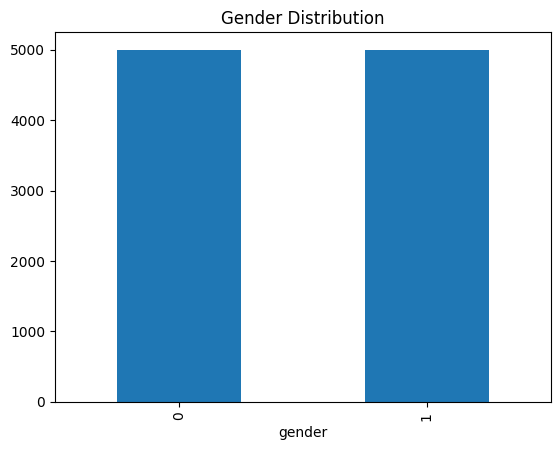

In [6]:
print (df ['gender'].value_counts ())
df ['gender'].value_counts ().plot (kind = 'bar')
plt.title ("Gender Distribution")
plt.show ()

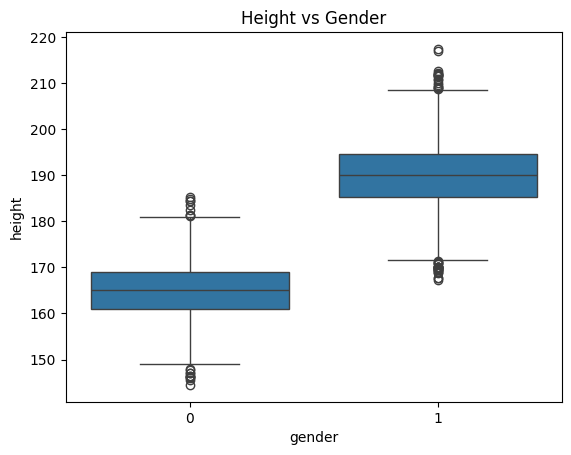

In [7]:
# height and gender
sns.boxplot (x= 'gender', y= 'height', data= df)
plt.title ("Height vs Gender")
plt.show ()

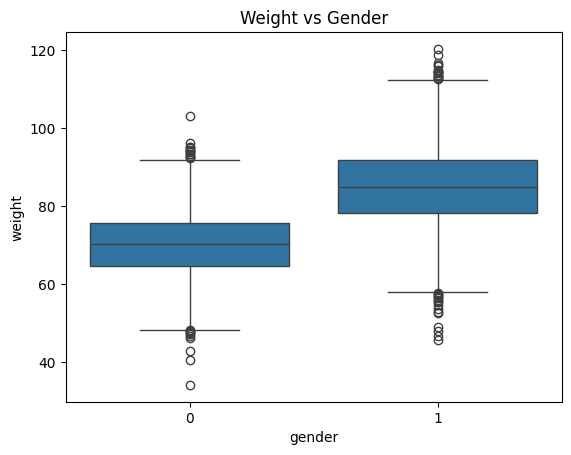

In [8]:
# Weight vs Gender
sns.boxplot (x= 'gender', y= 'weight', data= df)
plt.title ("Weight vs Gender")
plt.show ()

## Model Building

In [9]:
# Target (Y) and Features (X)
X = df [['height', 'weight', 'age']]  # Inputs
Y = df ['gender'] # Output

In [10]:
# Train and Test Split
X_train, X_test, Y_train, Y_test = train_test_split (
    X, Y, test_size= 0.2, random_state= 42
)

## Model: Logistic Regression

In [11]:
model = LogisticRegression ()
model.fit (X_train, Y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

## Prediction

In [12]:
y_pred = model.predict (X_test)
print ("Accuracy:", accuracy_score (Y_test, y_pred))

Accuracy: 0.9845


In [15]:
height = float (input ("Enter height: "))
weight = float (input ("Enter weight: "))
age = float (input ("Enter age: "))

new_df = pd.DataFrame ([[height, weight, age]], columns= ["height", "weight", "age"])

result = model.predict (new_df)

print ("Predicted Gender:", "Male" if result [0] == 1 else "Female")

Predicted Gender: Male


## Saving the model

In [14]:
with open ("gender_detection_model.pkl", "wb") as file:
    pickle.dump (model, file)